### Fig 1(a)

Self-consistent s-wave gap calculation for Fig. 1(a)
M                 = 0.5
mu                = 2.0
g                 = 1.57
target manifold   = upper
Nk                = 401 x 401
T range           = [0.001, 0.5]
n_T               = 101
calibrate to Tc   = True
channel weight    = 1.134461416171
estimated Tc      = 0.349999999999
Progress:   10/101, T = 0.045910, Delta = 0.6430761532
Progress:   20/101, T = 0.095810, Delta = 0.6423265745
Progress:   30/101, T = 0.145710, Delta = 0.6330515403
Progress:   40/101, T = 0.195610, Delta = 0.6024046516
Progress:   50/101, T = 0.245510, Delta = 0.5379177080
Progress:   60/101, T = 0.295410, Delta = 0.4183857201
Progress:   70/101, T = 0.345310, Delta = 0.1309490316
Progress:   80/101, T = 0.395210, Delta = 0.0000000000
Progress:   90/101, T = 0.445110, Delta = 0.0000000000
Progress:  100/101, T = 0.495010, Delta = 0.0000000000
Progress:  101/101, T = 0.500000, Delta = 0.0000000000
Saved data: fig1a_gap_vs_T/gap_vs_T_M0p5_mu2_g1p57.npz
Elapse

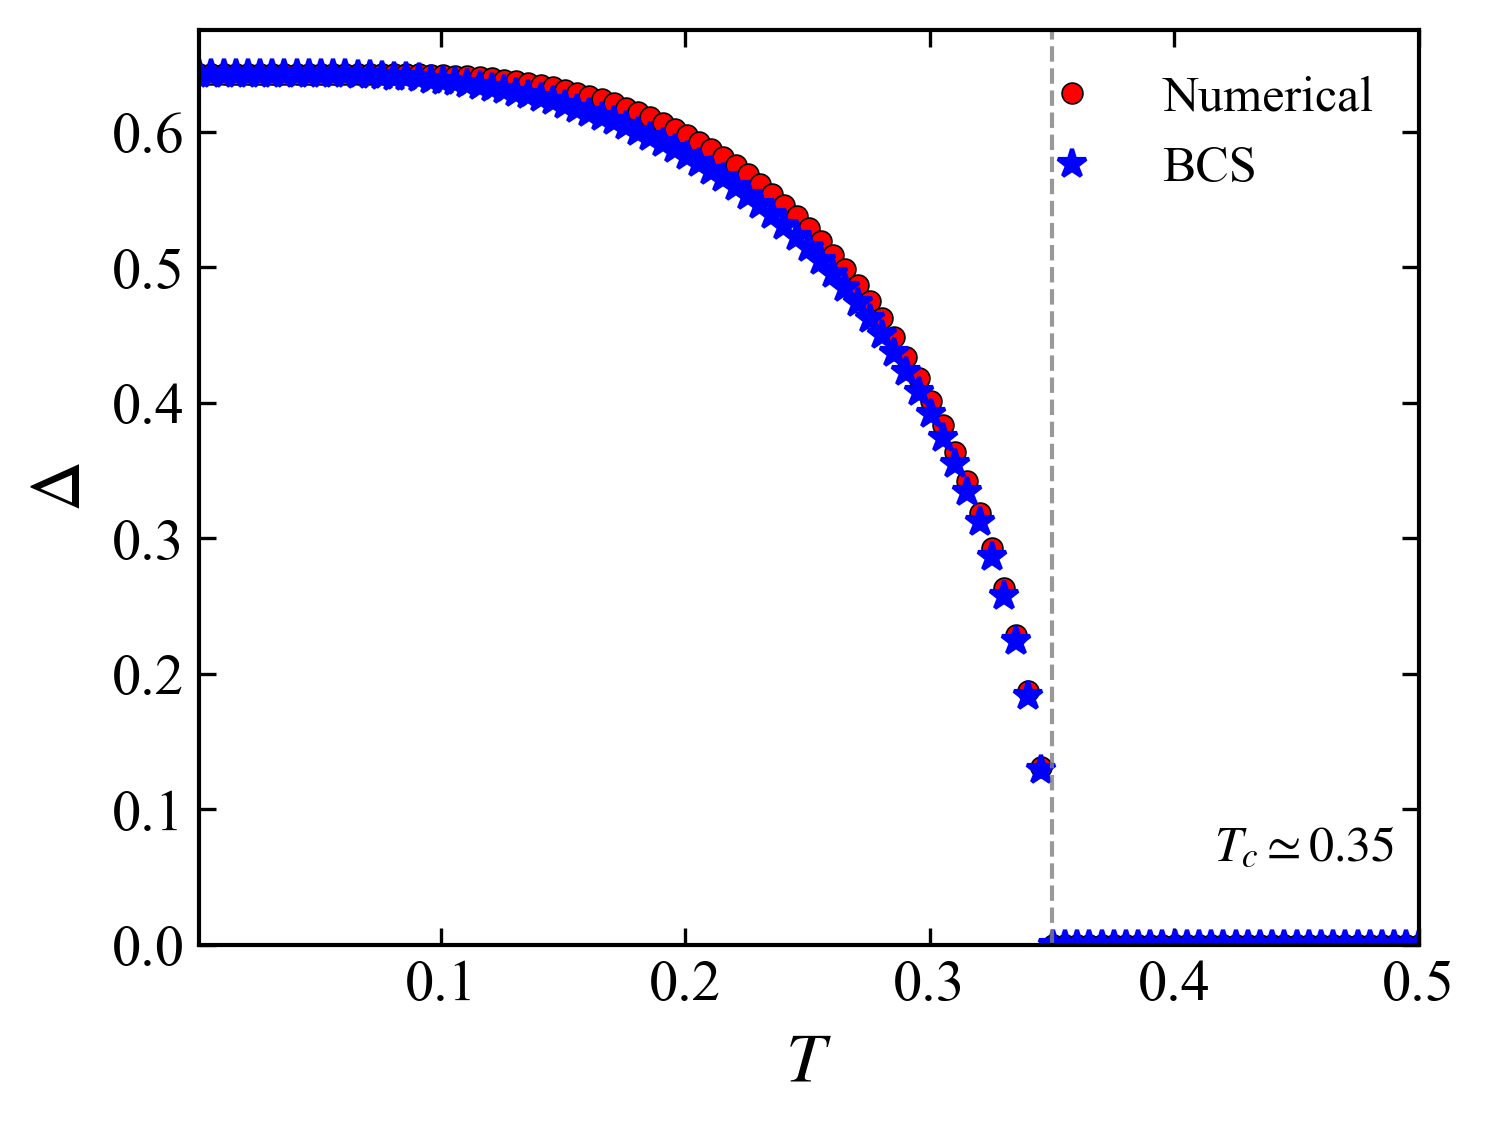

In [ ]:
import os
import json
import time
from dataclasses import dataclass, field, asdict

import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# Pauli matrices
# =========================================================
sigma0 = np.eye(2, dtype=complex)
sigmax = np.array([[0, 1], [1, 0]], dtype=complex)
sigmay = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigmaz = np.array([[1, 0], [0, -1]], dtype=complex)

s0 = np.eye(2, dtype=complex)
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)


def kron(a, b):
    return np.kron(a, b)


Gamma_zx = kron(sigmaz, sx)
Gamma_xx = kron(sigmax, sx)
Gamma_0z = kron(sigma0, sz)


# =========================================================
# Config
# =========================================================
@dataclass
class ModelParams:
    M: float = 0.5
    mu: float = 2.0
    g: float = 1.57

    # Which isolated degenerate manifold is used in the projected BdG problem.
    # For Fig. 1(a), the chemical potential mu=2 mainly intersects the upper manifold.
    # Options:
    #   "upper": epsilon = +|d| - mu
    #   "lower": epsilon = -|d| - mu
    #   "both":  include both manifolds
    target_manifold: str = "upper"


@dataclass
class CalcParams:
    Nk: int = 401

    T_min: float = 1e-3
    T_max: float = 0.50
    n_T: int = 101

    # The caption gives Tc ≈ 0.35 for g=1.57, M=0.5, mu=2.
    # Since the paper does not spell out every normalization factor in the
    # self-consistent gap equation for Fig. 1(a), this option calibrates the
    # overall channel weight so that the linearized gap equation gives target_Tc.
    calibrate_weight_to_Tc: bool = True
    target_Tc: float = 0.35

    # Used only when calibrate_weight_to_Tc = False.
    gap_channel_weight: float = 1.0

    # root solver
    gap_tol: float = 1e-11
    max_iter: int = 200

    output_dir: str = "fig1a_gap_vs_T"
    data_filename: str = "gap_vs_T_data.npz"


@dataclass
class PlotParams:
    figsize: tuple = (5.2, 4.0)
    dpi: int = 300

    font_size: float = 15
    label_size: float = 17
    tick_size: float = 14
    legend_size: float = 12

    show_figures: bool = True

    save_pdf: bool = True

    numerical_marker_size: float = 5.0
    bcs_marker_size: float = 7.0
    line_width: float = 1.6


@dataclass
class Config:
    model: ModelParams = field(default_factory=ModelParams)
    calc: CalcParams = field(default_factory=CalcParams)
    plot: PlotParams = field(default_factory=PlotParams)


# =========================================================
# Style
# =========================================================
def set_style(cfg):
    plt.rcParams["font.family"] = "Times New Roman"
    plt.rcParams["mathtext.fontset"] = "stix"
    plt.rcParams["font.size"] = cfg.plot.font_size

    plt.rcParams["axes.linewidth"] = 1.0
    plt.rcParams["xtick.direction"] = "in"
    plt.rcParams["ytick.direction"] = "in"
    plt.rcParams["xtick.top"] = True
    plt.rcParams["ytick.right"] = True
    plt.rcParams["xtick.major.size"] = 4
    plt.rcParams["ytick.major.size"] = 4


# =========================================================
# Normal-state lattice model
# =========================================================
def d_vector(kx, ky, M):
    d1 = np.sin(kx)
    d2 = -np.sin(ky)
    d3 = -(M - np.cos(kx) - np.cos(ky))
    return d1, d2, d3


def normal_hamiltonian(kx, ky, cfg):
    """
    4x4 normal-state Hamiltonian:
        H(k) = d1 Gamma_zx + d2 Gamma_xx + d3 Gamma_0z - mu I.
    """
    d1, d2, d3 = d_vector(kx, ky, cfg.model.M)

    H = (
        d1 * Gamma_zx
        + d2 * Gamma_xx
        + d3 * Gamma_0z
        - cfg.model.mu * np.eye(4, dtype=complex)
    )

    return H


def make_kmesh(cfg):
    """
    Uniform BZ mesh over [-pi, pi) x [-pi, pi).
    For this square BZ, integral d^2k/(2pi)^2 is just the average over k.
    """
    k_values = np.linspace(-np.pi, np.pi, cfg.calc.Nk, endpoint=False)
    kx, ky = np.meshgrid(k_values, k_values, indexing="ij")
    return kx, ky


def normal_band_energies_on_mesh(cfg):
    """
    The model has two twofold-degenerate manifolds:
        epsilon_+(k) = +|d(k)| - mu
        epsilon_-(k) = -|d(k)| - mu
    """
    kx, ky = make_kmesh(cfg)
    d1, d2, d3 = d_vector(kx, ky, cfg.model.M)

    dabs = np.sqrt(d1**2 + d2**2 + d3**2)

    xi_upper = +dabs - cfg.model.mu
    xi_lower = -dabs - cfg.model.mu

    return xi_upper, xi_lower


def selected_xi_list(cfg):
    xi_upper, xi_lower = normal_band_energies_on_mesh(cfg)

    if cfg.model.target_manifold == "upper":
        return [xi_upper]

    if cfg.model.target_manifold == "lower":
        return [xi_lower]

    if cfg.model.target_manifold == "both":
        return [xi_upper, xi_lower]

    raise ValueError("target_manifold must be 'upper', 'lower', or 'both'.")


# =========================================================
# Projected BdG Hamiltonian
# =========================================================
def projected_bdg_hamiltonian_from_xi(xi, Delta, Ndeg=2):
    """
    Projected BdG Hamiltonian for one isolated Ndeg-fold degenerate manifold.

    In the band basis used in the paper,
        H_BdG(k) = [[xi_k I_N, Delta B_k],
                    [Delta B_k^dagger, -xi_{-k} I_N]]

    At q=0 and for the TR-symmetric model, xi_k = xi_-k.
    The sewing matrix B_k is unitary, so the quasiparticle spectrum is
        E_k = sqrt(xi_k^2 + Delta^2),
    independent of the explicit gauge choice of B_k.

    Here we choose B_k = I_N for constructing a representative BdG matrix.
    """
    I = np.eye(Ndeg, dtype=complex)

    Hbdg = np.block(
        [
            [xi * I, Delta * I],
            [Delta * I, -xi * I],
        ]
    )

    return Hbdg


def projected_bdg_positive_energy(xi, Delta):
    """
    Positive BdG quasiparticle energy for one degenerate manifold.
    """
    return np.sqrt(xi**2 + Delta**2)


# =========================================================
# Gap equation
# =========================================================
def gap_kernel_for_one_xi(xi, Delta, T):
    """
    Kernel:
        < tanh(E/2T)/(2E) >_BZ

    where E = sqrt(xi^2 + Delta^2).
    """
    E = projected_bdg_positive_energy(xi, Delta)

    if T <= 0:
        return np.mean(1.0 / (2.0 * E))

    return np.mean(np.tanh(E / (2.0 * T)) / (2.0 * E))


def total_gap_kernel(Delta, T, cfg):
    """
    Sum over selected degenerate manifolds.

    The internal twofold degeneracy is not inserted explicitly here.
    Instead, its convention-dependent normalization is absorbed into
    gap_channel_weight. This makes the code easier to compare with Fig. 1(a).
    """
    xi_list = selected_xi_list(cfg)

    kernel = 0.0

    for xi in xi_list:
        kernel += gap_kernel_for_one_xi(xi, Delta, T)

    return kernel


def calibrated_gap_channel_weight(cfg):
    """
    Choose channel weight so that the linearized gap equation gives target_Tc:

        1/g = W * K(Delta=0, T=Tc)

    Hence
        W = 1 / [g * K(0, Tc)].
    """
    K_Tc = total_gap_kernel(Delta=0.0, T=cfg.calc.target_Tc, cfg=cfg)

    if K_Tc <= 0:
        raise RuntimeError("K(Tc) <= 0. Cannot calibrate gap channel weight.")

    W = 1.0 / (cfg.model.g * K_Tc)

    return W


def get_gap_channel_weight(cfg):
    if cfg.calc.calibrate_weight_to_Tc:
        return calibrated_gap_channel_weight(cfg)

    return cfg.calc.gap_channel_weight


def linearized_gap_equation_value(T, cfg, weight):
    """
    Return:
        W K(0,T) - 1/g.

    The critical temperature satisfies this value = 0.
    """
    return weight * total_gap_kernel(Delta=0.0, T=T, cfg=cfg) - 1.0 / cfg.model.g


def solve_gap_at_T(T, cfg, weight):
    """
    Solve:
        1/g = W * K(Delta,T)

    If no positive solution exists, return Delta = 0.
    """
    F0 = linearized_gap_equation_value(T, cfg, weight)

    if F0 <= 0:
        return 0.0

    def f(Delta):
        return weight * total_gap_kernel(Delta=Delta, T=T, cfg=cfg) - 1.0 / cfg.model.g

    Delta_low = 0.0
    Delta_high = 1.0

    while f(Delta_high) > 0:
        Delta_high *= 2.0

        if Delta_high > 100.0:
            raise RuntimeError("Failed to bracket the gap equation root.")

    for _ in range(cfg.calc.max_iter):
        Delta_mid = 0.5 * (Delta_low + Delta_high)

        if f(Delta_mid) > 0:
            Delta_low = Delta_mid
        else:
            Delta_high = Delta_mid

        if abs(Delta_high - Delta_low) < cfg.calc.gap_tol:
            break

    return 0.5 * (Delta_low + Delta_high)


def estimate_Tc(cfg, weight):
    """
    Estimate Tc from the linearized gap equation.
    """
    T_low = max(cfg.calc.T_min, 1e-8)
    T_high = max(cfg.calc.T_max, cfg.calc.target_Tc * 2.0, 1.0)

    f_low = linearized_gap_equation_value(T_low, cfg, weight)
    f_high = linearized_gap_equation_value(T_high, cfg, weight)

    while f_high > 0:
        T_high *= 2.0
        f_high = linearized_gap_equation_value(T_high, cfg, weight)

        if T_high > 100:
            raise RuntimeError("Failed to bracket Tc.")

    if f_low <= 0:
        return 0.0

    for _ in range(cfg.calc.max_iter):
        T_mid = 0.5 * (T_low + T_high)
        f_mid = linearized_gap_equation_value(T_mid, cfg, weight)

        if f_mid > 0:
            T_low = T_mid
        else:
            T_high = T_mid

        if abs(T_high - T_low) < cfg.calc.gap_tol:
            break

    return 0.5 * (T_low + T_high)


# =========================================================
# Standard BCS reference curve
# =========================================================
def bcs_reference_gap(T_values, Delta0, Tc):
    """
    Standard approximate BCS temperature dependence:
        Delta(T) = Delta(0) tanh[1.74 sqrt(Tc/T - 1)].
    """
    Delta_bcs = np.zeros_like(T_values, dtype=float)

    mask = (T_values > 0) & (T_values < Tc)

    x = Tc / T_values[mask] - 1.0
    Delta_bcs[mask] = Delta0 * np.tanh(1.74 * np.sqrt(x))

    return Delta_bcs


# =========================================================
# Calculation
# =========================================================
def run_calculation(cfg):
    os.makedirs(cfg.calc.output_dir, exist_ok=True)

    t0 = time.perf_counter()

    T_values = np.linspace(cfg.calc.T_min, cfg.calc.T_max, cfg.calc.n_T)

    weight = get_gap_channel_weight(cfg)
    Tc_est = estimate_Tc(cfg, weight)

    Delta_values = np.zeros_like(T_values, dtype=float)

    print("=" * 72)
    print("Self-consistent s-wave gap calculation for Fig. 1(a)")
    print("=" * 72)
    print(f"M                 = {cfg.model.M}")
    print(f"mu                = {cfg.model.mu}")
    print(f"g                 = {cfg.model.g}")
    print(f"target manifold   = {cfg.model.target_manifold}")
    print(f"Nk                = {cfg.calc.Nk} x {cfg.calc.Nk}")
    print(f"T range           = [{cfg.calc.T_min}, {cfg.calc.T_max}]")
    print(f"n_T               = {cfg.calc.n_T}")
    print(f"calibrate to Tc   = {cfg.calc.calibrate_weight_to_Tc}")
    print(f"channel weight    = {weight:.12f}")
    print(f"estimated Tc      = {Tc_est:.12f}")
    print("=" * 72)

    for iT, T in enumerate(T_values):
        Delta_values[iT] = solve_gap_at_T(T, cfg, weight)

        if (iT + 1) % max(1, cfg.calc.n_T // 10) == 0 or (iT + 1) == cfg.calc.n_T:
            print(
                f"Progress: {iT + 1:4d}/{cfg.calc.n_T}, "
                f"T = {T:.6f}, Delta = {Delta_values[iT]:.10f}"
            )

    Delta0_num = np.max(Delta_values)
    Delta_bcs = bcs_reference_gap(T_values, Delta0_num, Tc_est)

    elapsed = time.perf_counter() - t0

    out_file = os.path.join(cfg.calc.output_dir, cfg.calc.data_filename)

    np.savez_compressed(
        out_file,
        T_values=T_values,
        Delta_values=Delta_values,
        Delta_bcs=Delta_bcs,
        Tc_est=Tc_est,
        Delta0_num=Delta0_num,
        gap_channel_weight=weight,
        cfg_json=json.dumps(asdict(cfg), indent=2),
    )

    print("=" * 72)
    print(f"Saved data: {out_file}")
    print(f"Elapsed time: {elapsed:.3f} s")
    print("=" * 72)

    return out_file


# =========================================================
# Load data
# =========================================================
def load_gap_data(cfg):
    data_file = os.path.join(cfg.calc.output_dir, cfg.calc.data_filename)

    if not os.path.exists(data_file):
        raise FileNotFoundError(
            f"Cannot find data file:\n{data_file}\n"
            "Please run run_calculation(cfg) first."
        )

    data = np.load(data_file, allow_pickle=True)

    return {
        "T_values": data["T_values"],
        "Delta_values": data["Delta_values"],
        "Delta_bcs": data["Delta_bcs"],
        "Tc_est": float(data["Tc_est"]),
        "Delta0_num": float(data["Delta0_num"]),
        "gap_channel_weight": float(data["gap_channel_weight"]),
        "data_file": data_file,
    }


# =========================================================
# Plot
# =========================================================
def run_plotting(cfg):
    set_style(cfg)

    data = load_gap_data(cfg)

    T_values = data["T_values"]
    Delta_values = data["Delta_values"]
    Delta_bcs = data["Delta_bcs"]
    Tc_est = data["Tc_est"]

    print("=" * 72)
    print("Plotting Fig. 1(a)-type gap curve from saved data")
    print("=" * 72)
    print(f"Loaded data: {data['data_file']}")
    print(f"Tc_est     : {Tc_est:.8f}")
    print("=" * 72)

    fig, ax = plt.subplots(
        figsize=cfg.plot.figsize,
        dpi=cfg.plot.dpi,
    )

    ax.plot(
        T_values,
        Delta_values,
        "o",
        ms=cfg.plot.numerical_marker_size,
        color="red",
        markeredgecolor="black",
        markeredgewidth=0.4,
        label="Numerical",
    )

    ax.plot(
        T_values,
        Delta_bcs,
        "*",
        ms=cfg.plot.bcs_marker_size,
        color="blue",
        label="BCS",
    )

    ax.axvline(
        Tc_est,
        color="gray",
        lw=1.0,
        ls="--",
        alpha=0.8,
    )

    ax.text(
        0.98,
        0.08,
        rf"$T_c\simeq {Tc_est:.2f}$",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=cfg.plot.legend_size,
    )

    ax.set_xlabel(r"$T$", fontsize=cfg.plot.label_size)
    ax.set_ylabel(r"$\Delta$", fontsize=cfg.plot.label_size)

    ax.set_xlim(T_values[0], T_values[-1])
    ax.set_ylim(bottom=0)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=cfg.plot.tick_size,
    )

    ax.legend(
        frameon=False,
        fontsize=cfg.plot.legend_size,
        loc="upper right",
    )

    fig.tight_layout()

    out_png = os.path.join(cfg.calc.output_dir, "fig1a_gap_vs_T.png")
    fig.savefig(out_png, bbox_inches="tight")
    print(f"Saved figure: {out_png}")

    if cfg.plot.save_pdf:
        out_pdf = os.path.join(cfg.calc.output_dir, "fig1a_gap_vs_T.pdf")
        fig.savefig(out_pdf, bbox_inches="tight")
        print(f"Saved figure: {out_pdf}")

    if cfg.plot.show_figures:
        plt.show()

    plt.close(fig)

    return out_png


# =========================================================
# Build config
# =========================================================
def build_config():
    cfg = Config()

    # =====================================================
    # model parameters used in Fig. 1(a)
    # =====================================================
    cfg.model.M = 0.5
    cfg.model.mu = 2.0
    cfg.model.g = 1.57
    cfg.model.target_manifold = "upper"

    # =====================================================
    # calculation
    # =====================================================
    cfg.calc.Nk = 401

    cfg.calc.T_min = 1e-3
    cfg.calc.T_max = 0.50
    cfg.calc.n_T = 101

    cfg.calc.calibrate_weight_to_Tc = True
    cfg.calc.target_Tc = 0.35

    # Used only if calibrate_weight_to_Tc = False
    cfg.calc.gap_channel_weight = 1.0

    cfg.calc.output_dir = "fig1a_gap_vs_T"
    cfg.calc.data_filename = "gap_vs_T_M0p5_mu2_g1p57.npz"

    # =====================================================
    # plot
    # =====================================================
    cfg.plot.figsize = (5.2, 4.0)
    cfg.plot.dpi = 300
    cfg.plot.show_figures = True
    cfg.plot.save_pdf = False

    return cfg


# =========================================================
# Main switch for ipynb
# =========================================================
cfg = build_config()

# First run:
#   RUN_CALC = True
#   RUN_PLOT = True
#
# Later, if you only want to adjust plotting:
#   RUN_CALC = False
#   RUN_PLOT = True

RUN_CALC = True
RUN_PLOT = True

if RUN_CALC:
    run_calculation(cfg)

if RUN_PLOT:
    run_plotting(cfg)

### Fig 1 (b,c)

Plotting separate maps from saved data
Loaded: fig1bc_two_methods_QM/nonabelian_QM_two_methods_M0.5_upper_Nk301.npz
M: 0.5
target manifold: upper
dk: 2.08743698e-02


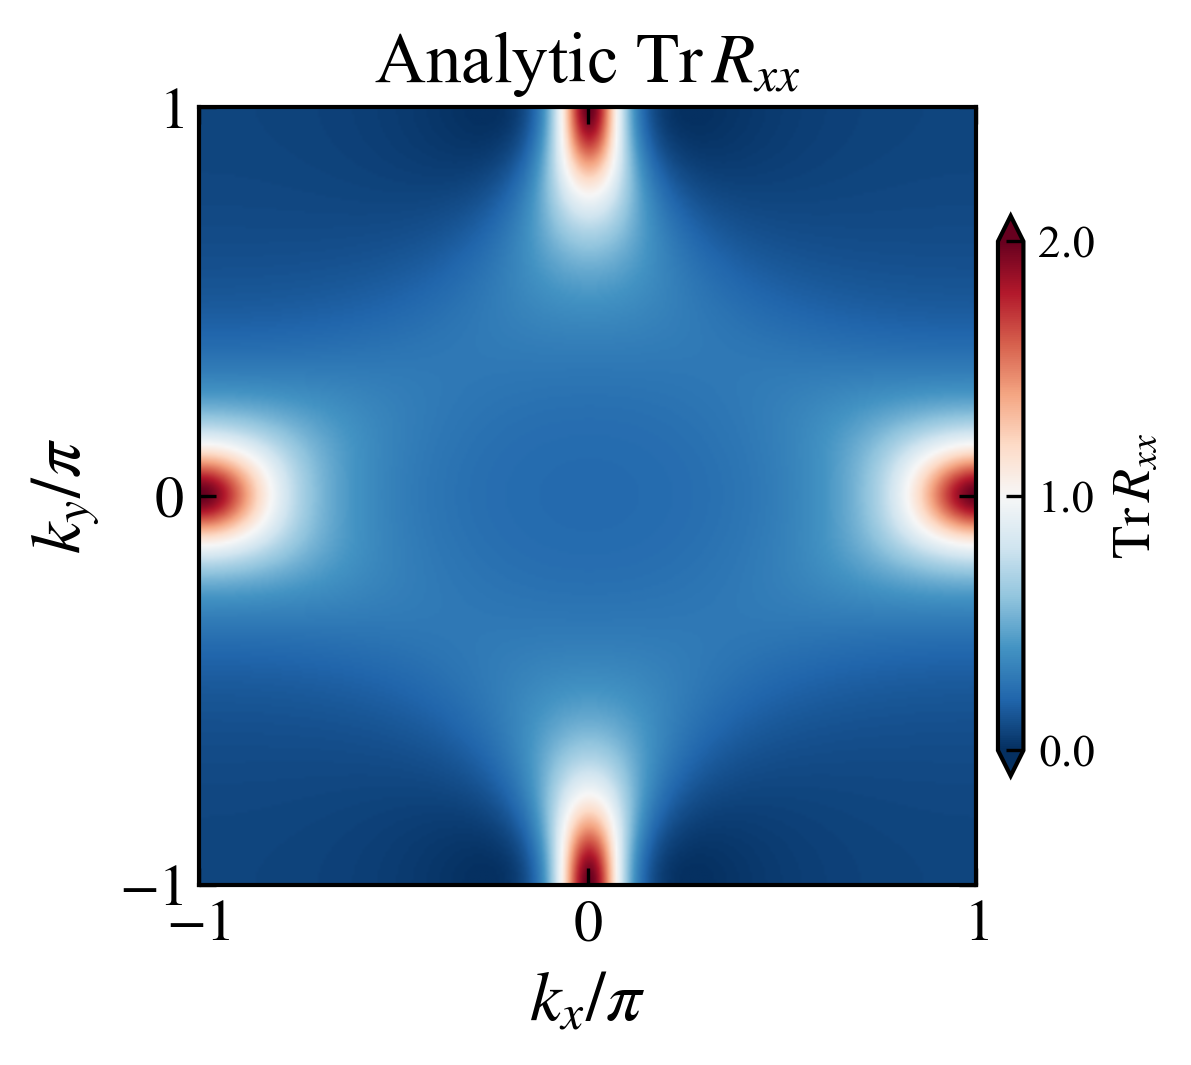

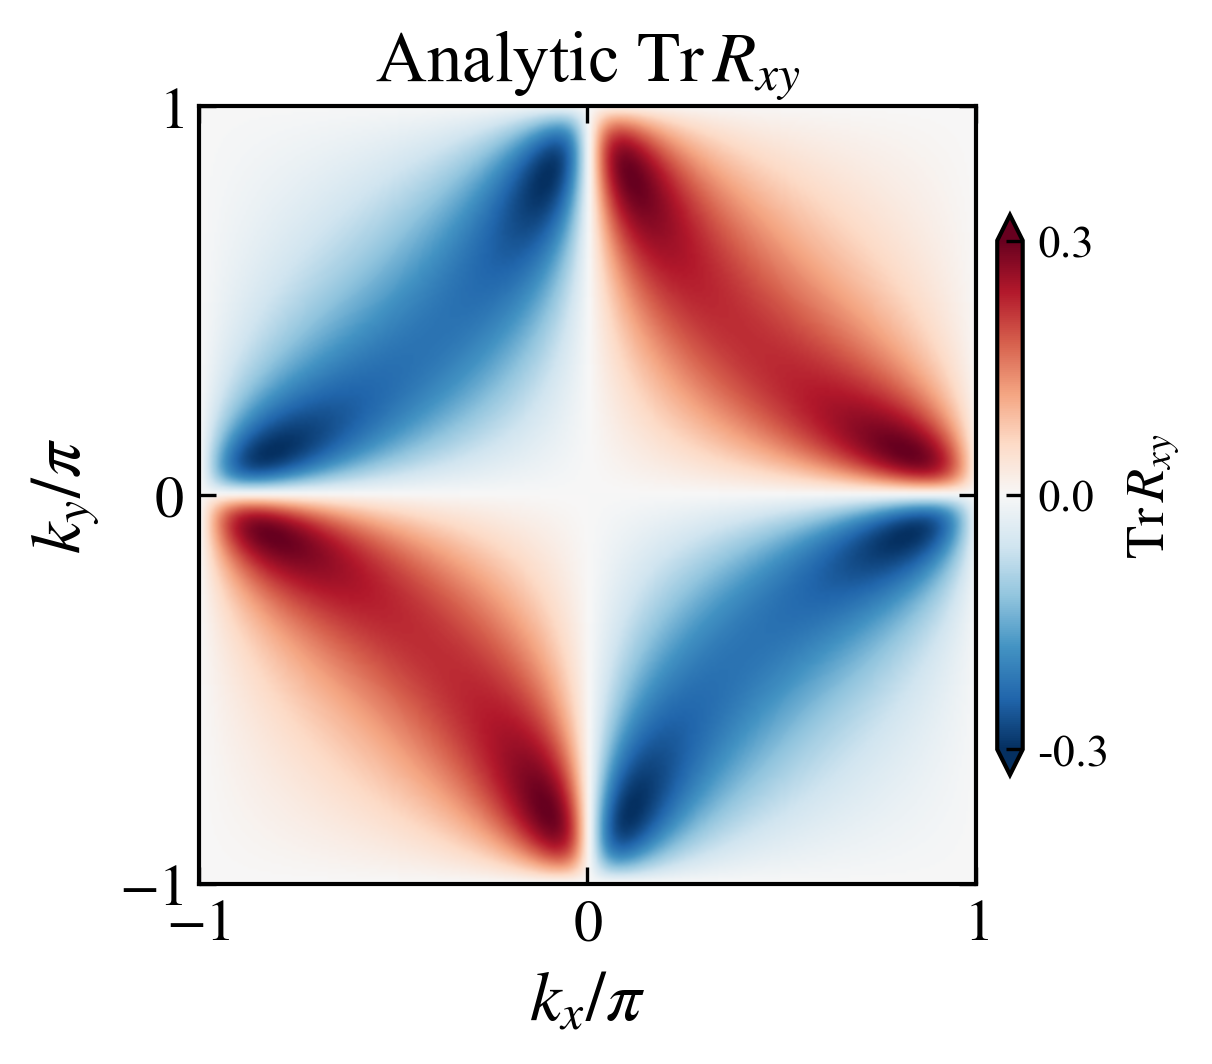

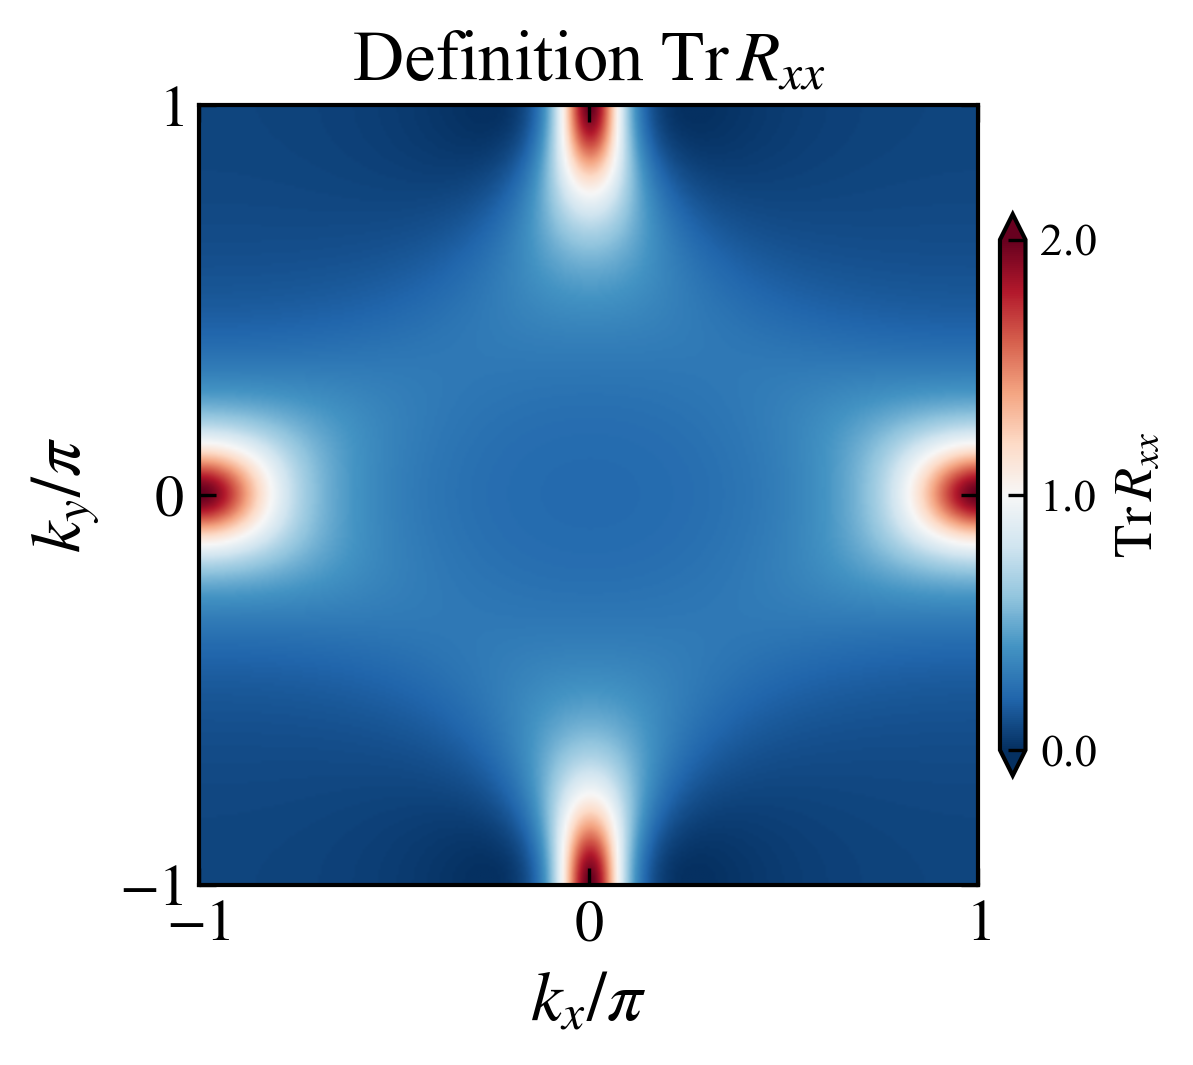

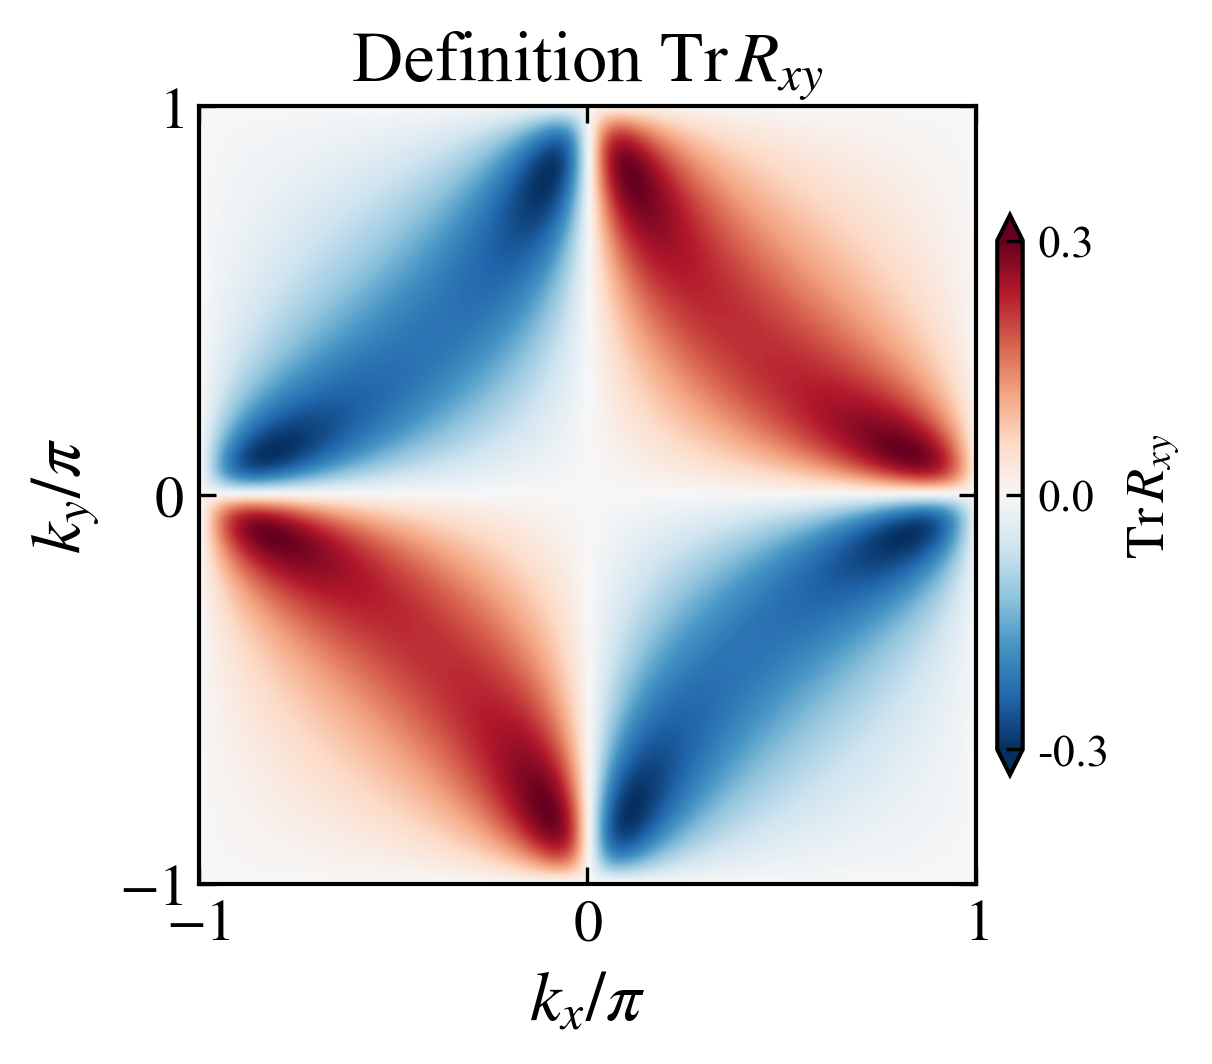

In [14]:
import os
import json
import time
from dataclasses import dataclass, field, asdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import FuncFormatter


# =========================================================
# Pauli matrices
# =========================================================
sigma0 = np.eye(2, dtype=complex)
sigmax = np.array([[0, 1], [1, 0]], dtype=complex)
sigmay = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigmaz = np.array([[1, 0], [0, -1]], dtype=complex)

s0 = np.eye(2, dtype=complex)
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)


def kron(a, b):
    return np.kron(a, b)


Gamma_zx = kron(sigmaz, sx)
Gamma_xx = kron(sigmax, sx)
Gamma_0z = kron(sigma0, sz)

I4 = np.eye(4, dtype=complex)


# =========================================================
# Config
# =========================================================
@dataclass
class ModelParams:
    M: float = 0.5

    # "upper" or "lower"
    target_manifold: str = "upper"


@dataclass
class CalcParams:
    Nk: int = 301

    k_min: float = -np.pi
    k_max: float = np.pi

    output_dir: str = "fig1bc_two_methods_QM"
    data_filename: str = "nonabelian_QM_two_methods_M0p5_Nk301.npz"


@dataclass
class PlotParams:
    dpi: int = 300

    figsize_single: tuple = (4.2, 3.8)

    font_size: float = 15
    label_size: float = 17
    tick_size: float = 14

    cbar_label_size: float = 13
    cbar_tick_size: float = 11

    cmap_Rxx: str = "viridis"
    cmap_Rxy: str = "RdBu_r"

    show_figures: bool = True
    save_pdf: bool = True

    # Axis ticks: at most three
    axis_ticks: tuple = (-1.0, 0.0, 1.0)
    axis_ticklabels: tuple = (r"$-1$", r"$0$", r"$1$")

    # Colorbar ticks: at most three
    n_cbar_ticks: int = 3

    # Colorbar tick label decimal places
    cbar_decimal: int = 1

    # Smaller colorbar
    cbar_pad: float = 0.025
    cbar_fraction: float = 0.040
    cbar_shrink: float = 0.72
    cbar_aspect: float = 22

    symmetric_Rxy: bool = True

    # Image interpolation
    interpolation: str = "bilinear"

    fig_dirname: str = "figures"


@dataclass
class Config:
    model: ModelParams = field(default_factory=ModelParams)
    calc: CalcParams = field(default_factory=CalcParams)
    plot: PlotParams = field(default_factory=PlotParams)


# =========================================================
# Style
# =========================================================
def set_style(cfg):
    plt.rcParams["font.family"] = "Times New Roman"
    plt.rcParams["mathtext.fontset"] = "stix"

    plt.rcParams["font.size"] = cfg.plot.font_size

    plt.rcParams["axes.linewidth"] = 1.0

    plt.rcParams["xtick.direction"] = "in"
    plt.rcParams["ytick.direction"] = "in"

    plt.rcParams["xtick.top"] = True
    plt.rcParams["ytick.right"] = True

    plt.rcParams["xtick.major.size"] = 4
    plt.rcParams["ytick.major.size"] = 4


# =========================================================
# k mesh
# =========================================================
def make_kmesh(cfg):
    """
    Periodic mesh on [-pi, pi).

    Shape convention:
        KX, KY: (Nk, Nk)
        axis 0: ky direction
        axis 1: kx direction
    """
    k_values = np.linspace(
        cfg.calc.k_min,
        cfg.calc.k_max,
        cfg.calc.Nk,
        endpoint=False,
    )

    KX, KY = np.meshgrid(
        k_values,
        k_values,
        indexing="xy",
    )

    dk = (cfg.calc.k_max - cfg.calc.k_min) / cfg.calc.Nk

    return k_values, k_values, KX, KY, dk


# =========================================================
# d-vector and Hamiltonian
# =========================================================
def d_vector(kx, ky, M):
    """
    Article model:
        d1 = sin(kx)
        d2 = -sin(ky)
        d3 = -(M - cos(kx) - cos(ky))
           = -M + cos(kx) + cos(ky)
    """
    d1 = np.sin(kx)
    d2 = -np.sin(ky)
    d3 = -M + np.cos(kx) + np.cos(ky)

    return d1, d2, d3


def d_vector_derivatives(kx, ky):
    """
    d = (sin kx, -sin ky, -M + cos kx + cos ky)

    partial_kx d = (cos kx, 0, -sin kx)
    partial_ky d = (0, -cos ky, -sin ky)
    """
    ddx = np.stack(
        [
            np.cos(kx),
            np.zeros_like(kx),
            -np.sin(kx),
        ],
        axis=-1,
    )

    ddy = np.stack(
        [
            np.zeros_like(ky),
            -np.cos(ky),
            -np.sin(ky),
        ],
        axis=-1,
    )

    return ddx, ddy


def hamiltonian_without_mu(kx, ky, M):
    """
    H0(k) = d1 Gamma_zx + d2 Gamma_xx + d3 Gamma_0z
    """
    d1, d2, d3 = d_vector(kx, ky, M)

    H0 = (
        d1 * Gamma_zx
        + d2 * Gamma_xx
        + d3 * Gamma_0z
    )

    return H0


# =========================================================
# Method 1: analytic expression from the paper
# =========================================================
def analytic_metric_trace(KX, KY, M):
    """
    Method 1:
        Tr R_{mu nu}(k)
        = 1/2 partial_mu d_hat · partial_nu d_hat.
    """
    d1, d2, d3 = d_vector(KX, KY, M)

    d = np.stack([d1, d2, d3], axis=-1)

    d_norm = np.sqrt(np.sum(d * d, axis=-1))

    if np.any(d_norm < 1e-12):
        print("Warning: |d| nearly zero. Metric may be singular.")

    ddx, ddy = d_vector_derivatives(KX, KY)

    d_dot_ddx = np.sum(d * ddx, axis=-1)
    d_dot_ddy = np.sum(d * ddy, axis=-1)

    ddhat_x = (
        ddx / d_norm[..., None]
        - d * d_dot_ddx[..., None] / (d_norm[..., None] ** 3)
    )

    ddhat_y = (
        ddy / d_norm[..., None]
        - d * d_dot_ddy[..., None] / (d_norm[..., None] ** 3)
    )

    Rxx = 0.5 * np.sum(ddhat_x * ddhat_x, axis=-1)
    Rxy = 0.5 * np.sum(ddhat_x * ddhat_y, axis=-1)
    Ryy = 0.5 * np.sum(ddhat_y * ddhat_y, axis=-1)

    return Rxx, Rxy, Ryy


# =========================================================
# Method 2: definition through projector
# =========================================================
def projectors_on_mesh(KX, KY, M, target_manifold):
    """
    Construct the projector onto a twofold-degenerate manifold.

    Since H0(k) = d_i Gamma_i and Gamma_i anticommute,
    the two projectors are

        P_upper = [I + H0/|d|]/2
        P_lower = [I - H0/|d|]/2

    This avoids the arbitrary U(2) gauge problem of degenerate eigenvectors.
    """
    d1, d2, d3 = d_vector(KX, KY, M)

    d_norm = np.sqrt(d1**2 + d2**2 + d3**2)

    if np.any(d_norm < 1e-12):
        print("Warning: |d| nearly zero. Projector may be singular.")

    hhat = (
        (d1 / d_norm)[..., None, None] * Gamma_zx
        + (d2 / d_norm)[..., None, None] * Gamma_xx
        + (d3 / d_norm)[..., None, None] * Gamma_0z
    )

    if target_manifold == "upper":
        Pmesh = 0.5 * (I4[None, None, :, :] + hhat)

    elif target_manifold == "lower":
        Pmesh = 0.5 * (I4[None, None, :, :] - hhat)

    else:
        raise ValueError("target_manifold must be 'upper' or 'lower'.")

    return Pmesh


def definition_metric_trace_from_projector(Pmesh, dk):
    """
    Method 2:
        Tr R_{mu nu}
        = 1/2 Re Tr[(partial_mu P)(partial_nu P)].

    Periodic central difference:
        partial_x P = [P(k+dk_x) - P(k-dk_x)] / (2 dk)
        partial_y P = [P(k+dk_y) - P(k-dk_y)] / (2 dk)
    """
    dPdx = (
        np.roll(Pmesh, shift=-1, axis=1)
        - np.roll(Pmesh, shift=1, axis=1)
    ) / (2.0 * dk)

    dPdy = (
        np.roll(Pmesh, shift=-1, axis=0)
        - np.roll(Pmesh, shift=1, axis=0)
    ) / (2.0 * dk)

    Rxx = 0.5 * np.real(
        np.einsum("...ab,...ba->...", dPdx, dPdx)
    )

    Rxy = 0.5 * np.real(
        np.einsum("...ab,...ba->...", dPdx, dPdy)
    )

    Ryy = 0.5 * np.real(
        np.einsum("...ab,...ba->...", dPdy, dPdy)
    )

    return Rxx, Rxy, Ryy


# =========================================================
# Calculation
# =========================================================
def run_calculation(cfg):
    os.makedirs(cfg.calc.output_dir, exist_ok=True)

    t0 = time.perf_counter()

    kx_values, ky_values, KX, KY, dk = make_kmesh(cfg)

    print("=" * 72)
    print("Computing non-Abelian quantum metric by two methods")
    print("=" * 72)
    print(f"M               = {cfg.model.M}")
    print(f"target manifold = {cfg.model.target_manifold}")
    print(f"Nk              = {cfg.calc.Nk} x {cfg.calc.Nk}")
    print(f"dk              = {dk:.8e}")
    print("=" * 72)

    # Method 1: analytic expression
    Rxx_ana, Rxy_ana, Ryy_ana = analytic_metric_trace(
        KX,
        KY,
        cfg.model.M,
    )

    # Method 2: definition from projector
    Pmesh = projectors_on_mesh(
        KX,
        KY,
        cfg.model.M,
        cfg.model.target_manifold,
    )

    Rxx_def, Rxy_def, Ryy_def = definition_metric_trace_from_projector(
        Pmesh,
        dk,
    )

    out_file = os.path.join(
        cfg.calc.output_dir,
        cfg.calc.data_filename,
    )

    np.savez_compressed(
        out_file,
        kx_values=kx_values,
        ky_values=ky_values,
        Rxx_analytic=Rxx_ana,
        Rxy_analytic=Rxy_ana,
        Ryy_analytic=Ryy_ana,
        Rxx_definition=Rxx_def,
        Rxy_definition=Rxy_def,
        Ryy_definition=Ryy_def,
        M=cfg.model.M,
        target_manifold=cfg.model.target_manifold,
        dk=dk,
        cfg_json=json.dumps(asdict(cfg), indent=2),
    )

    elapsed = time.perf_counter() - t0

    print("=" * 72)
    print("-" * 72)
    print("Analytic method")
    print(f"Rxx min/max = {np.nanmin(Rxx_ana):.8e}, {np.nanmax(Rxx_ana):.8e}")
    print(f"Rxy min/max = {np.nanmin(Rxy_ana):.8e}, {np.nanmax(Rxy_ana):.8e}")
    print("-" * 72)
    print("Definition method")
    print(f"Rxx min/max = {np.nanmin(Rxx_def):.8e}, {np.nanmax(Rxx_def):.8e}")
    print(f"Rxy min/max = {np.nanmin(Rxy_def):.8e}, {np.nanmax(Rxy_def):.8e}")
    print("-" * 72)
    print(f"Elapsed: {elapsed:.3f} s")
    print("=" * 72)

    return out_file


# =========================================================
# Load data
# =========================================================
def load_data(cfg):
    data_file = os.path.join(
        cfg.calc.output_dir,
        cfg.calc.data_filename,
    )

    if not os.path.exists(data_file):
        raise FileNotFoundError(
            f"Cannot find data file:\n{data_file}\n"
            "Please run run_calculation(cfg) first."
        )

    data = np.load(data_file, allow_pickle=True)

    return {
        "kx_values": data["kx_values"],
        "ky_values": data["ky_values"],
        "Rxx_analytic": data["Rxx_analytic"],
        "Rxy_analytic": data["Rxy_analytic"],
        "Ryy_analytic": data["Ryy_analytic"],
        "Rxx_definition": data["Rxx_definition"],
        "Rxy_definition": data["Rxy_definition"],
        "Ryy_definition": data["Ryy_definition"],
        "M": float(data["M"]),
        "target_manifold": str(data["target_manifold"]),
        "dk": float(data["dk"]),
        "data_file": data_file,
    }


# =========================================================
# Plot helpers
# =========================================================
def set_k_axis(ax, cfg):
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)

    ax.set_xticks(list(cfg.plot.axis_ticks))
    ax.set_yticks(list(cfg.plot.axis_ticks))

    ax.set_xticklabels(list(cfg.plot.axis_ticklabels))
    ax.set_yticklabels(list(cfg.plot.axis_ticklabels))

    ax.set_xlabel(r"$k_x/\pi$", fontsize=cfg.plot.label_size)
    ax.set_ylabel(r"$k_y/\pi$", fontsize=cfg.plot.label_size)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=cfg.plot.tick_size,
    )

    ax.set_aspect("equal")


def format_cbar_tick(x, pos, decimal=1):
    """
    Format colorbar tick labels.

    Default:
        decimal = 1 gives labels like 0.0, 0.5, 1.0.

    Avoid -0.0.
    """
    threshold = 0.5 * 10 ** (-decimal)

    if abs(x) < threshold:
        x = 0.0

    return f"{x:.{decimal}f}"


def set_cbar_ticks(cbar, vmin, vmax, cfg):
    ticks = np.linspace(vmin, vmax, cfg.plot.n_cbar_ticks)
    cbar.set_ticks(ticks)

    cbar.ax.yaxis.set_major_formatter(
        FuncFormatter(
            lambda x, pos: format_cbar_tick(
                x,
                pos,
                decimal=cfg.plot.cbar_decimal,
            )
        )
    )

    cbar.ax.tick_params(labelsize=cfg.plot.cbar_tick_size)


def plot_single_map(
    cfg,
    Z,
    title,
    cbar_label,
    cmap,
    out_basename,
    symmetric=False,
):
    set_style(cfg)

    fig, ax = plt.subplots(
        figsize=cfg.plot.figsize_single,
        dpi=cfg.plot.dpi,
    )

    if symmetric:
        vmax = np.nanmax(np.abs(Z))

        if vmax < 1e-15:
            vmax = 1e-15

        norm = TwoSlopeNorm(
            vmin=-vmax,
            vcenter=0.0,
            vmax=vmax,
        )

        vmin_for_ticks = -vmax
        vmax_for_ticks = vmax

    else:
        norm = None
        vmin_for_ticks = np.nanmin(Z)
        vmax_for_ticks = np.nanmax(Z)

    im = ax.imshow(
        Z,
        origin="lower",
        extent=[-1.0, 1.0, -1.0, 1.0],
        cmap=cmap,
        norm=norm,
        interpolation=cfg.plot.interpolation,
        aspect="equal",
    )

    set_k_axis(ax, cfg)

    ax.set_title(title, fontsize=cfg.plot.label_size)

    cbar = fig.colorbar(
        im,
        ax=ax,
        pad=cfg.plot.cbar_pad,
        fraction=cfg.plot.cbar_fraction,
        shrink=cfg.plot.cbar_shrink,
        aspect=cfg.plot.cbar_aspect,
        extend = "both"
    )

    cbar.set_label(
        cbar_label,
        fontsize=cfg.plot.cbar_label_size,
    )

    set_cbar_ticks(
        cbar,
        vmin_for_ticks,
        vmax_for_ticks,
        cfg,
    )

    fig.tight_layout()

    fig_dir = os.path.join(
        cfg.calc.output_dir,
        cfg.plot.fig_dirname,
    )

    os.makedirs(fig_dir, exist_ok=True)

    out_png = os.path.join(
        fig_dir,
        f"{out_basename}.png",
    )

    fig.savefig(out_png, bbox_inches="tight")

    if cfg.plot.save_pdf:
        out_pdf = os.path.join(
            fig_dir,
            f"{out_basename}.pdf",
        )

        fig.savefig(out_pdf, bbox_inches="tight")

    if cfg.plot.show_figures:
        plt.show()

    plt.close(fig)

    return out_png


# =========================================================
# Plotting
# =========================================================
def run_plotting(cfg):
    data = load_data(cfg)

    print("=" * 72)
    print("Plotting separate maps from saved data")
    print("=" * 72)
    print(f"Loaded: {data['data_file']}")
    print(f"M: {data['M']}")
    print(f"target manifold: {data['target_manifold']}")
    print(f"dk: {data['dk']:.8e}")
    print("=" * 72)

    # -----------------------------
    # Analytic Rxx
    # -----------------------------
    plot_single_map(
        cfg=cfg,
        Z=data["Rxx_analytic"],
        title=r"Analytic $\mathrm{Tr}\,R_{xx}$",
        cbar_label=r"$\mathrm{Tr}\,R_{xx}$",
        cmap=cfg.plot.cmap_Rxx,
        out_basename="analytic_TrRxx",
        symmetric=False,
    )

    # -----------------------------
    # Analytic Rxy
    # -----------------------------
    plot_single_map(
        cfg=cfg,
        Z=data["Rxy_analytic"],
        title=r"Analytic $\mathrm{Tr}\,R_{xy}$",
        cbar_label=r"$\mathrm{Tr}\,R_{xy}$",
        cmap=cfg.plot.cmap_Rxy,
        out_basename="analytic_TrRxy",
        symmetric=cfg.plot.symmetric_Rxy,
    )

    # -----------------------------
    # Definition Rxx
    # -----------------------------
    plot_single_map(
        cfg=cfg,
        Z=data["Rxx_definition"],
        title=r"Definition $\mathrm{Tr}\,R_{xx}$",
        cbar_label=r"$\mathrm{Tr}\,R_{xx}$",
        cmap=cfg.plot.cmap_Rxx,
        out_basename="definition_TrRxx",
        symmetric=False,
    )

    # -----------------------------
    # Definition Rxy
    # -----------------------------
    plot_single_map(
        cfg=cfg,
        Z=data["Rxy_definition"],
        title=r"Definition $\mathrm{Tr}\,R_{xy}$",
        cbar_label=r"$\mathrm{Tr}\,R_{xy}$",
        cmap=cfg.plot.cmap_Rxy,
        out_basename="definition_TrRxy",
        symmetric=cfg.plot.symmetric_Rxy,
    )


# =========================================================
# Build config
# =========================================================
def build_config():
    cfg = Config()

    # =====================================================
    # model
    # =====================================================
    cfg.model.M = 0.5

    # "upper" or "lower"
    cfg.model.target_manifold = "upper"

    # =====================================================
    # calculation
    # =====================================================
    cfg.calc.Nk = 301

    cfg.calc.k_min = -np.pi
    cfg.calc.k_max = np.pi

    cfg.calc.output_dir = "fig1bc_two_methods_QM"

    cfg.calc.data_filename = (
        f"nonabelian_QM_two_methods_"
        f"M{cfg.model.M}_"
        f"{cfg.model.target_manifold}_"
        f"Nk{cfg.calc.Nk}.npz"
    )

    # =====================================================
    # plot
    # =====================================================
    cfg.plot.dpi = 300

    cfg.plot.figsize_single = (4.2, 3.8)

    cfg.plot.cmap_Rxx = "RdBu_r"
    cfg.plot.cmap_Rxy = "RdBu_r"

    # Axis labels: at most three ticks
    cfg.plot.axis_ticks = (-1.0, 0.0, 1.0)
    cfg.plot.axis_ticklabels = (r"$-1$", r"$0$", r"$1$")

    # Colorbar: at most three ticks
    cfg.plot.n_cbar_ticks = 3

    # Colorbar tick decimal places
    cfg.plot.cbar_decimal = 1

    # Smaller colorbar
    cfg.plot.cbar_pad = 0.025
    cfg.plot.cbar_fraction = 0.040
    cfg.plot.cbar_shrink = 0.72
    cfg.plot.cbar_aspect = 22

    cfg.plot.cbar_label_size = 13
    cfg.plot.cbar_tick_size = 11

    cfg.plot.symmetric_Rxy = True

    cfg.plot.interpolation = "bilinear"

    cfg.plot.fig_dirname = "figures"

    cfg.plot.show_figures = True
    cfg.plot.save_pdf = False

    return cfg


# =========================================================
# Main switch for ipynb
# =========================================================
cfg = build_config()

# First run:
#   RUN_CALC = True
#   RUN_PLOT = True
#
# Later, if you only want to adjust plotting:
#   RUN_CALC = False
#   RUN_PLOT = True

RUN_CALC = False
RUN_PLOT = True

if RUN_CALC:
    run_calculation(cfg)

if RUN_PLOT:
    run_plotting(cfg)

# Fig 1(d)

Plotting Fig. 1(d) from saved data
Loaded: fig1d_superfluid_weight/fig1d_SW_vs_M_mu2.0_T0.2_Nk501_dq0.001.npz
Saved figure: fig1d_superfluid_weight/figures/fig1d_superfluid_weight_vs_M.png


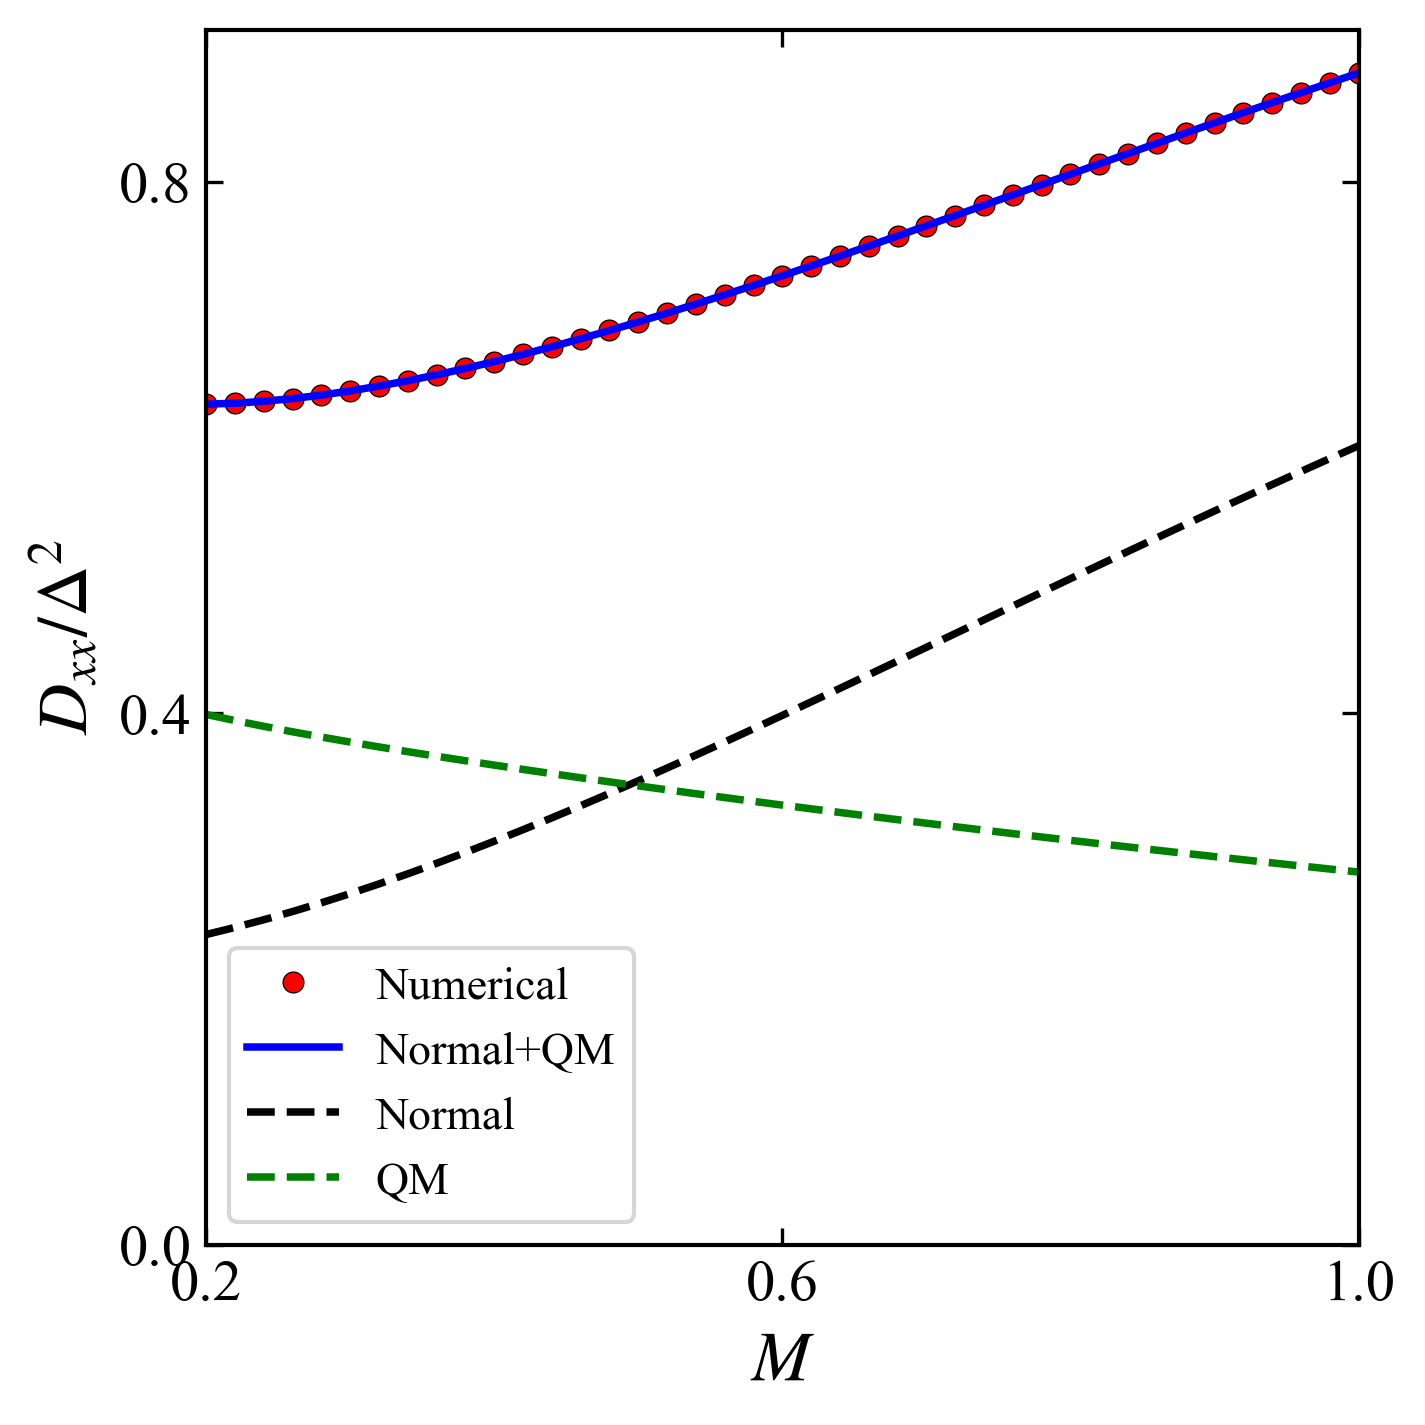

In [ ]:
import os
import json
import time
from dataclasses import dataclass, field, asdict
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# =========================================================
# Pauli matrices
# =========================================================
sigma0 = np.eye(2, dtype=complex)
sigmax = np.array([[0, 1], [1, 0]], dtype=complex)
sigmay = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigmaz = np.array([[1, 0], [0, -1]], dtype=complex)

s0 = np.eye(2, dtype=complex)
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)


def kron(a, b):
    return np.kron(a, b)


Gamma_zx = kron(sigmaz, sx)
Gamma_xx = kron(sigmax, sx)
Gamma_0z = kron(sigma0, sz)

I4 = np.eye(4, dtype=complex)

# Time-reversal operator:
# Theta = U_T K, with U_T = sigma0 tensor sz
U_T = kron(sigma0, sz)


# =========================================================
# Config
# =========================================================
@dataclass
class ModelParams:
    mu: float = 2.0

    # target manifold:
    # "upper": epsilon = +|d| - mu
    # "lower": epsilon = -|d| - mu
    target_manifold: str = "upper"


@dataclass
class CalcParams:
    Nk: int = 501

    M_min: float = 0.2
    M_max: float = 1.0
    n_M: int = 41

    # The paper uses formulas near Tc.
    # Fig. 1(a) gives Tc ~ 0.35 for M=0.5, mu=2.
    # T=0.30 is a reasonable default below Tc.
    T: float = 0.30

    # finite difference step for Cooper-pair momentum qx
    dq: float = 1e-3

    # Factor used to match Eq. (8) convention.
    # Set to 1.0 if you want literal second derivative d^2F/dq^2.
    stiffness_prefactor: float = 0.5

    output_dir: str = "fig1d_superfluid_weight"
    data_filename: str = "fig1d_SW_vs_M.npz"


@dataclass
class PlotParams:
    dpi: int = 300
    figsize: tuple = (5.0, 4.0)

    font_size: float = 15
    label_size: float = 17
    tick_size: float = 14
    legend_size: float = 11

    line_width: float = 1.8
    marker_size: float = 5.0

    show_figures: bool = True
    save_pdf: bool = True

    # At most three major tick labels
    x_ticks: tuple = (0.2, 0.6, 1.0)
    y_ticks: tuple = (0.0, 0.4, 0.8)

    tick_decimal: int = 1

    fig_dirname: str = "figures"


@dataclass
class Config:
    model: ModelParams = field(default_factory=ModelParams)
    calc: CalcParams = field(default_factory=CalcParams)
    plot: PlotParams = field(default_factory=PlotParams)


# =========================================================
# Style
# =========================================================
def set_style(cfg):
    plt.rcParams["font.family"] = "Times New Roman"
    plt.rcParams["mathtext.fontset"] = "stix"

    plt.rcParams["font.size"] = cfg.plot.font_size

    plt.rcParams["axes.linewidth"] = 1.0

    plt.rcParams["xtick.direction"] = "in"
    plt.rcParams["ytick.direction"] = "in"

    plt.rcParams["xtick.top"] = True
    plt.rcParams["ytick.right"] = True

    plt.rcParams["xtick.major.size"] = 4
    plt.rcParams["ytick.major.size"] = 4


# =========================================================
# k mesh
# =========================================================
def make_kmesh(cfg):
    k_values = np.linspace(
        -np.pi,
        np.pi,
        cfg.calc.Nk,
        endpoint=False,
    )

    KX, KY = np.meshgrid(k_values, k_values, indexing="xy")

    return KX, KY


# =========================================================
# d-vector and band energy
# =========================================================
def d_vector(kx, ky, M):
    """
    d1 = sin(kx)
    d2 = -sin(ky)
    d3 = -(M - cos(kx) - cos(ky))
       = -M + cos(kx) + cos(ky)
    """
    d1 = np.sin(kx)
    d2 = -np.sin(ky)
    d3 = -M + np.cos(kx) + np.cos(ky)

    return d1, d2, d3


def d_abs(kx, ky, M):
    d1, d2, d3 = d_vector(kx, ky, M)

    return np.sqrt(d1**2 + d2**2 + d3**2)


def band_energy(kx, ky, M, cfg):
    """
    Target twofold-degenerate manifold.
    """
    absd = d_abs(kx, ky, M)

    if cfg.model.target_manifold == "upper":
        return +absd - cfg.model.mu

    if cfg.model.target_manifold == "lower":
        return -absd - cfg.model.mu

    raise ValueError("target_manifold must be 'upper' or 'lower'.")


# =========================================================
# Non-Abelian metric trace
# =========================================================
def d_vector_derivatives(kx, ky):
    ddx = np.stack(
        [
            np.cos(kx),
            np.zeros_like(kx),
            -np.sin(kx),
        ],
        axis=-1,
    )

    ddy = np.stack(
        [
            np.zeros_like(ky),
            -np.cos(ky),
            -np.sin(ky),
        ],
        axis=-1,
    )

    return ddx, ddy


def trace_Rxx_analytic(kx, ky, M):
    """
    Tr R_xx = 1/2 partial_x d_hat dot partial_x d_hat.
    """
    d1, d2, d3 = d_vector(kx, ky, M)

    d = np.stack([d1, d2, d3], axis=-1)
    norm = np.sqrt(np.sum(d * d, axis=-1))

    ddx, _ = d_vector_derivatives(kx, ky)

    d_dot_ddx = np.sum(d * ddx, axis=-1)

    ddhat_x = (
        ddx / norm[..., None]
        - d * d_dot_ddx[..., None] / (norm[..., None] ** 3)
    )

    Rxx = 0.5 * np.sum(ddhat_x * ddhat_x, axis=-1)

    return Rxx


# =========================================================
# Projector for numerical full free energy
# =========================================================
def projector(kx, ky, M, cfg):
    """
    Projector onto upper/lower twofold-degenerate manifold.

    H0 = d_i Gamma_i, eigenvalues are +- |d|.
    P_upper = (I + H0/|d|)/2
    P_lower = (I - H0/|d|)/2
    """
    d1, d2, d3 = d_vector(kx, ky, M)
    norm = np.sqrt(d1**2 + d2**2 + d3**2)

    hhat = (
        (d1 / norm)[..., None, None] * Gamma_zx
        + (d2 / norm)[..., None, None] * Gamma_xx
        + (d3 / norm)[..., None, None] * Gamma_0z
    )

    if cfg.model.target_manifold == "upper":
        P = 0.5 * (I4[None, None, :, :] + hhat)

    elif cfg.model.target_manifold == "lower":
        P = 0.5 * (I4[None, None, :, :] - hhat)

    else:
        raise ValueError("target_manifold must be 'upper' or 'lower'.")

    return P


def time_reversed_projector(P):
    r"""
    Theta P Theta^{-1} = U_T P^* U_T^{\dagger}.
    """
    return np.einsum(
        "ab,...bc,cd->...ad",
        U_T,
        P.conj(),
        U_T.conj().T,
    )


def trace_pairing_overlap(kx, ky, M, qx, cfg):
    r"""
    Gauge-invariant expression:

        Tr[Delta^{\dagger} Delta] / Delta^2
        = Tr[P_{k+q} Theta P_{-k+q} Theta^{-1}].
    """
    P_a = projector(
        kx + qx,
        ky,
        M,
        cfg,
    )

    P_b = projector(
        -kx + qx,
        -ky,
        M,
        cfg,
    )

    Q_b = time_reversed_projector(P_b)

    tr_val = np.real(
        np.einsum("...ab,...ba->...", P_a, Q_b)
    )

    return tr_val


# =========================================================
# Fermi function and stable kernels
# =========================================================
def fermi(x, T):
    y = np.clip(x / T, -700.0, 700.0)
    return 1.0 / (np.exp(y) + 1.0)


def tanh_over_x(x, T):
    """
    Return tanh[x/(2T)] / x with stable x -> 0 limit 1/(2T).
    """
    out = np.empty_like(x, dtype=float)

    small = np.abs(x) < 1e-10

    out[~small] = np.tanh(x[~small] / (2.0 * T)) / x[~small]
    out[small] = 1.0 / (2.0 * T)

    return out


def A_kernel(kx, ky, M, qx, cfg):
    """
    A(k,q) =
    [nF(epsilon_{k+q}) - nF(-epsilon_{-k+q})]
    /
    [epsilon_{k+q} + epsilon_{-k+q}]
    """
    T = cfg.calc.T

    eps_plus = band_energy(
        kx + qx,
        ky,
        M,
        cfg,
    )

    eps_minus = band_energy(
        -kx + qx,
        -ky,
        M,
        cfg,
    )

    numerator = fermi(eps_plus, T) - fermi(-eps_minus, T)
    denominator = eps_plus + eps_minus

    out = np.empty_like(denominator, dtype=float)

    small = np.abs(denominator) < 1e-10

    out[~small] = numerator[~small] / denominator[~small]

    # At q=0:
    # [f(e)-f(-e)]/(2e) = -tanh(e/2T)/(2e)
    # small-e limit = -1/(4T)
    out[small] = -1.0 / (4.0 * T)

    return out


# =========================================================
# Superfluid weight contributions
# =========================================================
def compute_D_QM_xx_over_Delta2(M, KX, KY, cfg):
    """
    Paper Eq. (8) convention:

        D_QM_xx / Delta^2
        = < Tr R_xx(k) tanh(epsilon/2T) / epsilon >_BZ.
    """
    eps = band_energy(KX, KY, M, cfg)
    Rxx = trace_Rxx_analytic(KX, KY, M)

    integrand = Rxx * tanh_over_x(eps, cfg.calc.T)

    return np.mean(integrand)


def free_energy_normal_over_Delta2(M, KX, KY, qx, cfg):
    """
    F_N(q) / Delta^2, excluding the q-independent 1/g term.

        F_N / Delta^2 = N/2 < A(k,q) >

    N = 2 for the twofold-degenerate target subspace.
    """
    Ndeg = 2.0

    A = A_kernel(KX, KY, M, qx, cfg)

    return 0.5 * Ndeg * np.mean(A)


def free_energy_full_over_Delta2(M, KX, KY, qx, cfg):
    r"""
    Full second-order free energy in the target degenerate manifold:

        F_full / Delta^2
        = 1/2 < Tr[Delta^{\dagger} Delta]/Delta^2 * A(k,q) >

    with the trace evaluated gauge-invariantly from projectors.
    """
    A = A_kernel(KX, KY, M, qx, cfg)

    tr_overlap = trace_pairing_overlap(KX, KY, M, qx, cfg)

    return 0.5 * np.mean(tr_overlap * A)


def second_derivative_qx(func, M, KX, KY, cfg):
    dq = cfg.calc.dq

    f_plus = func(M, KX, KY, +dq, cfg)
    f_zero = func(M, KX, KY, 0.0, cfg)
    f_minus = func(M, KX, KY, -dq, cfg)

    second_deriv = (f_plus + f_minus - 2.0 * f_zero) / (dq**2)

    return cfg.calc.stiffness_prefactor * second_deriv


def compute_D_N_xx_over_Delta2(M, KX, KY, cfg):
    return second_derivative_qx(
        free_energy_normal_over_Delta2,
        M,
        KX,
        KY,
        cfg,
    )


def compute_D_num_xx_over_Delta2(M, KX, KY, cfg):
    return second_derivative_qx(
        free_energy_full_over_Delta2,
        M,
        KX,
        KY,
        cfg,
    )


# =========================================================
# Calculation
# =========================================================
def run_calculation(cfg):
    os.makedirs(cfg.calc.output_dir, exist_ok=True)

    KX, KY = make_kmesh(cfg)

    M_values = np.linspace(
        cfg.calc.M_min,
        cfg.calc.M_max,
        cfg.calc.n_M,
    )

    D_N = np.zeros_like(M_values, dtype=float)
    D_QM = np.zeros_like(M_values, dtype=float)
    D_sum = np.zeros_like(M_values, dtype=float)
    D_num = np.zeros_like(M_values, dtype=float)

    t0 = time.perf_counter()

    print("=" * 72)
    print("Computing Fig. 1(d): superfluid weight vs M")
    print("=" * 72)
    print(f"target manifold      = {cfg.model.target_manifold}")
    print(f"mu                   = {cfg.model.mu}")
    print(f"T                    = {cfg.calc.T}")
    print(f"Nk                   = {cfg.calc.Nk} x {cfg.calc.Nk}")
    print(f"M range              = [{cfg.calc.M_min}, {cfg.calc.M_max}]")
    print(f"n_M                  = {cfg.calc.n_M}")
    print(f"dq                   = {cfg.calc.dq}")
    print(f"stiffness_prefactor  = {cfg.calc.stiffness_prefactor}")
    print("=" * 72)

    for i, M in enumerate(M_values):

        D_QM[i] = compute_D_QM_xx_over_Delta2(M, KX, KY, cfg)
        D_N[i] = compute_D_N_xx_over_Delta2(M, KX, KY, cfg)
        D_sum[i] = D_N[i] + D_QM[i]
        D_num[i] = compute_D_num_xx_over_Delta2(M, KX, KY, cfg)

        print(
            f"M = {M:.4f} | "
            f"D_N = {D_N[i]:.8f}, "
            f"D_QM = {D_QM[i]:.8f}, "
            f"D_sum = {D_sum[i]:.8f}, "
            f"D_num = {D_num[i]:.8f}"
        )

    elapsed = time.perf_counter() - t0

    out_file = os.path.join(
        cfg.calc.output_dir,
        cfg.calc.data_filename,
    )

    np.savez_compressed(
        out_file,
        M_values=M_values,
        D_N_over_Delta2=D_N,
        D_QM_over_Delta2=D_QM,
        D_sum_over_Delta2=D_sum,
        D_num_over_Delta2=D_num,
        cfg_json=json.dumps(asdict(cfg), indent=2),
    )

    print("=" * 72)
    print(f"Saved data: {out_file}")
    print(f"Elapsed: {elapsed:.3f} s")
    print("=" * 72)

    return out_file


# =========================================================
# Load data
# =========================================================
def load_data(cfg):
    data_file = os.path.join(
        cfg.calc.output_dir,
        cfg.calc.data_filename,
    )

    if not os.path.exists(data_file):
        raise FileNotFoundError(
            f"Cannot find data file:\n{data_file}\n"
            "Please run run_calculation(cfg) first."
        )

    data = np.load(data_file, allow_pickle=True)

    return {
        "M_values": data["M_values"],
        "D_N": data["D_N_over_Delta2"],
        "D_QM": data["D_QM_over_Delta2"],
        "D_sum": data["D_sum_over_Delta2"],
        "D_num": data["D_num_over_Delta2"],
        "data_file": data_file,
    }


# =========================================================
# Plot helpers
# =========================================================
def tick_formatter(x, pos, decimal=1):
    threshold = 0.5 * 10 ** (-decimal)

    if abs(x) < threshold:
        x = 0.0

    return f"{x:.{decimal}f}"


def run_plotting(cfg):
    set_style(cfg)

    data = load_data(cfg)

    M_values = data["M_values"]
    D_N = data["D_N"]
    D_QM = data["D_QM"]
    D_sum = data["D_sum"]
    D_num = data["D_num"]

    print("=" * 72)
    print("Plotting Fig. 1(d) from saved data")
    print("=" * 72)
    print(f"Loaded: {data['data_file']}")
    print("=" * 72)

    fig, ax = plt.subplots(
        figsize=cfg.plot.figsize,
        dpi=cfg.plot.dpi,
    )

    ax.plot(
        M_values,
        D_num,
        "o",
        ms=cfg.plot.marker_size,
        color="red",
        markeredgecolor="black",
        markeredgewidth=0.3,
        label="Numerical",
    )

    ax.plot(
        M_values,
        D_sum,
        "-",
        lw=cfg.plot.line_width,
        color="blue",
        label="Normal+QM",
    )

    ax.plot(
        M_values,
        D_N,
        "--",
        lw=cfg.plot.line_width,
        color="black",
        label="Normal",
    )

    ax.plot(
        M_values,
        D_QM,
        "--",
        lw=cfg.plot.line_width,
        color="green",
        label="QM",
    )

    ax.set_xlabel(r"$M$", fontsize=cfg.plot.label_size)
    ax.set_ylabel(r"$D_{xx}/\Delta^2$", fontsize=cfg.plot.label_size)

    ax.set_xlim(cfg.calc.M_min, cfg.calc.M_max)

    ax.set_xticks(list(cfg.plot.x_ticks))
    ax.set_yticks(list(cfg.plot.y_ticks))

    ax.xaxis.set_major_formatter(
        FuncFormatter(
            lambda x, pos: tick_formatter(
                x,
                pos,
                decimal=cfg.plot.tick_decimal,
            )
        )
    )

    ax.yaxis.set_major_formatter(
        FuncFormatter(
            lambda y, pos: tick_formatter(
                y,
                pos,
                decimal=cfg.plot.tick_decimal,
            )
        )
    )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=cfg.plot.tick_size,
    )

    ax.legend(
        frameon=True,
        fontsize=cfg.plot.legend_size,
        loc="best",
    )

    fig.tight_layout()

    fig_dir = os.path.join(
        cfg.calc.output_dir,
        cfg.plot.fig_dirname,
    )

    os.makedirs(fig_dir, exist_ok=True)

    out_png = os.path.join(
        fig_dir,
        "fig1d_superfluid_weight_vs_M.png",
    )

    fig.savefig(out_png, bbox_inches="tight")
    print(f"Saved figure: {out_png}")

    if cfg.plot.save_pdf:
        out_pdf = os.path.join(
            fig_dir,
            "fig1d_superfluid_weight_vs_M.pdf",
        )

        fig.savefig(out_pdf, bbox_inches="tight")
        print(f"Saved figure: {out_pdf}")

    if cfg.plot.show_figures:
        plt.show()

    plt.close(fig)

    return out_png


# =========================================================
# Build config
# =========================================================
def build_config():
    cfg = Config()

    # =====================================================
    # model
    # =====================================================
    cfg.model.mu = 2.0
    cfg.model.target_manifold = "upper"

    # =====================================================
    # calculation
    # =====================================================
    cfg.calc.Nk = 501

    cfg.calc.M_min = 0.2
    cfg.calc.M_max = 1.0
    cfg.calc.n_M = 41

    # Temperature below Tc ~ 0.35 from Fig. 1(a)
    cfg.calc.T = 0.2

    # finite-q step
    cfg.calc.dq = 1e-3

    # Paper Eq. (8)-consistent normalization
    cfg.calc.stiffness_prefactor = 0.5

    cfg.calc.output_dir = "fig1d_superfluid_weight"
    cfg.calc.data_filename = (
        f"fig1d_SW_vs_M_"
        f"mu{cfg.model.mu}_"
        f"T{cfg.calc.T}_"
        f"Nk{cfg.calc.Nk}_"
        f"dq{cfg.calc.dq}.npz"
    )

    # =====================================================
    # plot
    # =====================================================
    cfg.plot.dpi = 300
    cfg.plot.figsize = (5.0, 5.0)

    cfg.plot.x_ticks = (0.2, 0.6, 1.0)
    cfg.plot.y_ticks = (0.0, 0.4, 0.8)

    cfg.plot.tick_decimal = 1

    cfg.plot.fig_dirname = "figures"

    cfg.plot.show_figures = True
    cfg.plot.save_pdf = False

    return cfg
# =========================================================
# Main switch for ipynb
# =========================================================
cfg = build_config()

# First run:
#   RUN_CALC = True
#   RUN_PLOT = True
#
# Later, if you only want to adjust plotting:
#   RUN_CALC = False
#   RUN_PLOT = True

RUN_CALC = False
RUN_PLOT = True

if RUN_CALC:
    run_calculation(cfg)

if RUN_PLOT:
    run_plotting(cfg)